# Chronic Wasting Disease (CWD) — Exploratory Data Analysis
### Wild and Captive Positive Cervid Distribution Across U.S. States

**Author:** Dr. Maria Julia Judson, DVM, MSc  
**Data Source:** U.S. Geological Survey (USGS) — CWD Distribution in the US by State and County (ver. 3.0, June 2025)  
**Tools:** Python (pandas, matplotlib, seaborn) · Power BI

---

## Project Overview

This notebook explores the geographic distribution of Chronic Wasting Disease (CWD) in both wild and captive cervid populations across the United States. The analysis identifies spatial patterns, ranks states by number of affected counties, and compares disease burden between wild and captive populations. Outputs are designed to feed an interactive Power BI dashboard for exploratory visualization.

**Objectives:**
1. Identify states with the highest number of CWD-affected counties
2. Compare disease distribution between wild and captive populations
3. Prepare clean, aggregated datasets for Power BI visualization

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

---
## 2. Load Data

In [2]:
# Load raw USGS datasets
wild_df = pd.read_csv("20250408_CWD_Wild.csv")
captive_df = pd.read_csv("20250408_CWD_Captive.csv")

# Standardize column names
wild_df.columns = wild_df.columns.str.lower().str.strip()
captive_df.columns = captive_df.columns.str.lower().str.strip()

print(f"Wild dataset: {wild_df.shape[0]} rows, {wild_df.shape[1]} columns")
print(f"Captive dataset: {captive_df.shape[0]} rows, {captive_df.shape[1]} columns")

Wild dataset: 593 rows, 2 columns
Captive dataset: 166 rows, 3 columns


---
## 3. Data Exploration

In [4]:
print("--- Wild Dataset ---")
display(wild_df.head())
print("--- Captive Dataset ---")
display(captive_df.head())

--- Wild Dataset ---


,state,county
0,Alabama,Colbert
1,Alabama,Lauderdale
2,Arkansas,Baxter
3,Arkansas,Benton
4,Arkansas,Boone


--- Captive Dataset ---


,state,county,count
0,Colorado,Delta,2
1,Colorado,Eagle,2
2,Colorado,El Paso,1
3,Colorado,Fremont,1
4,Colorado,Garfield,1


### Summary Statistics

In [6]:
# Aggregate: count affected counties per state
wild_summary = wild_df["state"].value_counts().reset_index()
wild_summary.columns = ["state", "wild_CWD_affected_counties"]

captive_summary = captive_df["state"].value_counts().reset_index()
captive_summary.columns = ["state", "captive_CWD_affected_counties"]

# Key figures
num_wild_states = len(wild_summary)
total_wild_counties = wild_summary["wild_CWD_affected_counties"].sum()

num_captive_states = len(captive_summary)
total_captive_counties = captive_summary["captive_CWD_affected_counties"].sum()

print(f"Wild CWD:    {num_wild_states} states affected | {total_wild_counties} total counties")
print(f"Captive CWD: {num_captive_states} states affected | {total_captive_counties} total counties")
print(f"""
Wild CWD covers {num_wild_states - num_captive_states} more states and "
      f"{total_wild_counties - total_captive_counties} more counties than captive CWD.""")

Wild CWD:    36 states affected | 593 total counties
Captive CWD: 22 states affected | 166 total counties

Wild CWD covers 14 more states and "
      f"427 more counties than captive CWD.


---
## 4. Wild CWD Distribution

CWD presence in free-ranging cervid populations, measured by number of affected counties per state.

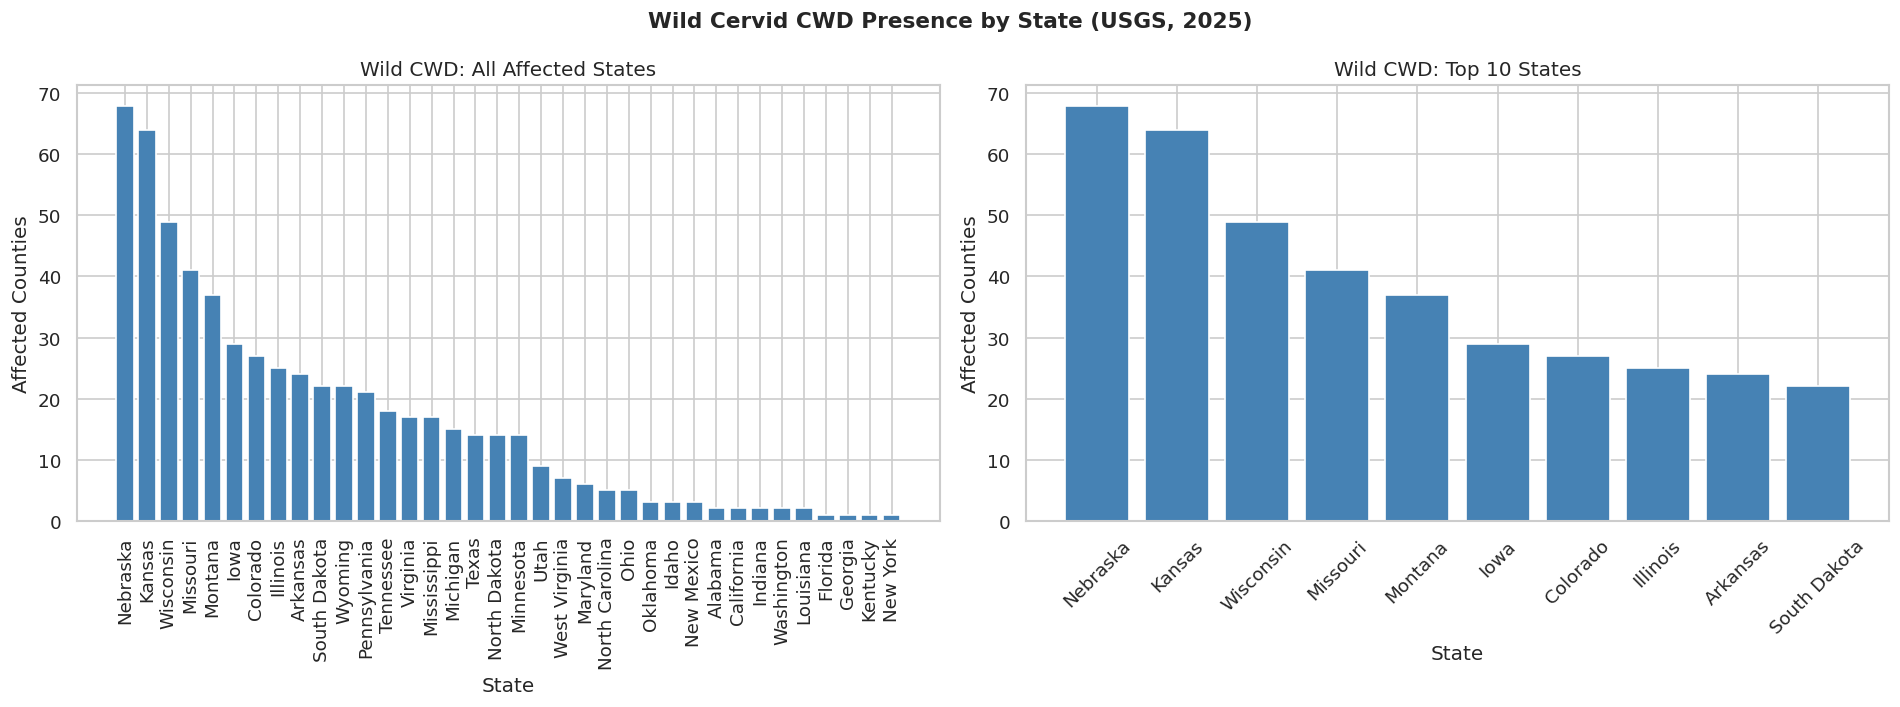

In [7]:
wild_sorted = wild_summary.sort_values(by="wild_CWD_affected_counties", ascending=False)
top10_wild = wild_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All states
axes[0].bar(wild_sorted["state"], wild_sorted["wild_CWD_affected_counties"], color="steelblue")
axes[0].set_title("Wild CWD: All Affected States")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Affected Counties")
axes[0].tick_params(axis="x", rotation=90)

# Top 10
axes[1].bar(top10_wild["state"], top10_wild["wild_CWD_affected_counties"], color="steelblue")
axes[1].set_title("Wild CWD: Top 10 States")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Affected Counties")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Wild Cervid CWD Presence by State (USGS, 2025)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** Among the 36 affected states, Nebraska leads with 68 CWD-positive counties, followed by Kansas and Wisconsin. Eastern states (e.g., New York) show minimal presence (1 county), consistent with a Midwestern geographic concentration of the disease.

---
## 5. Captive CWD Distribution

CWD presence in captive cervids, measured by number of affected counties per state.

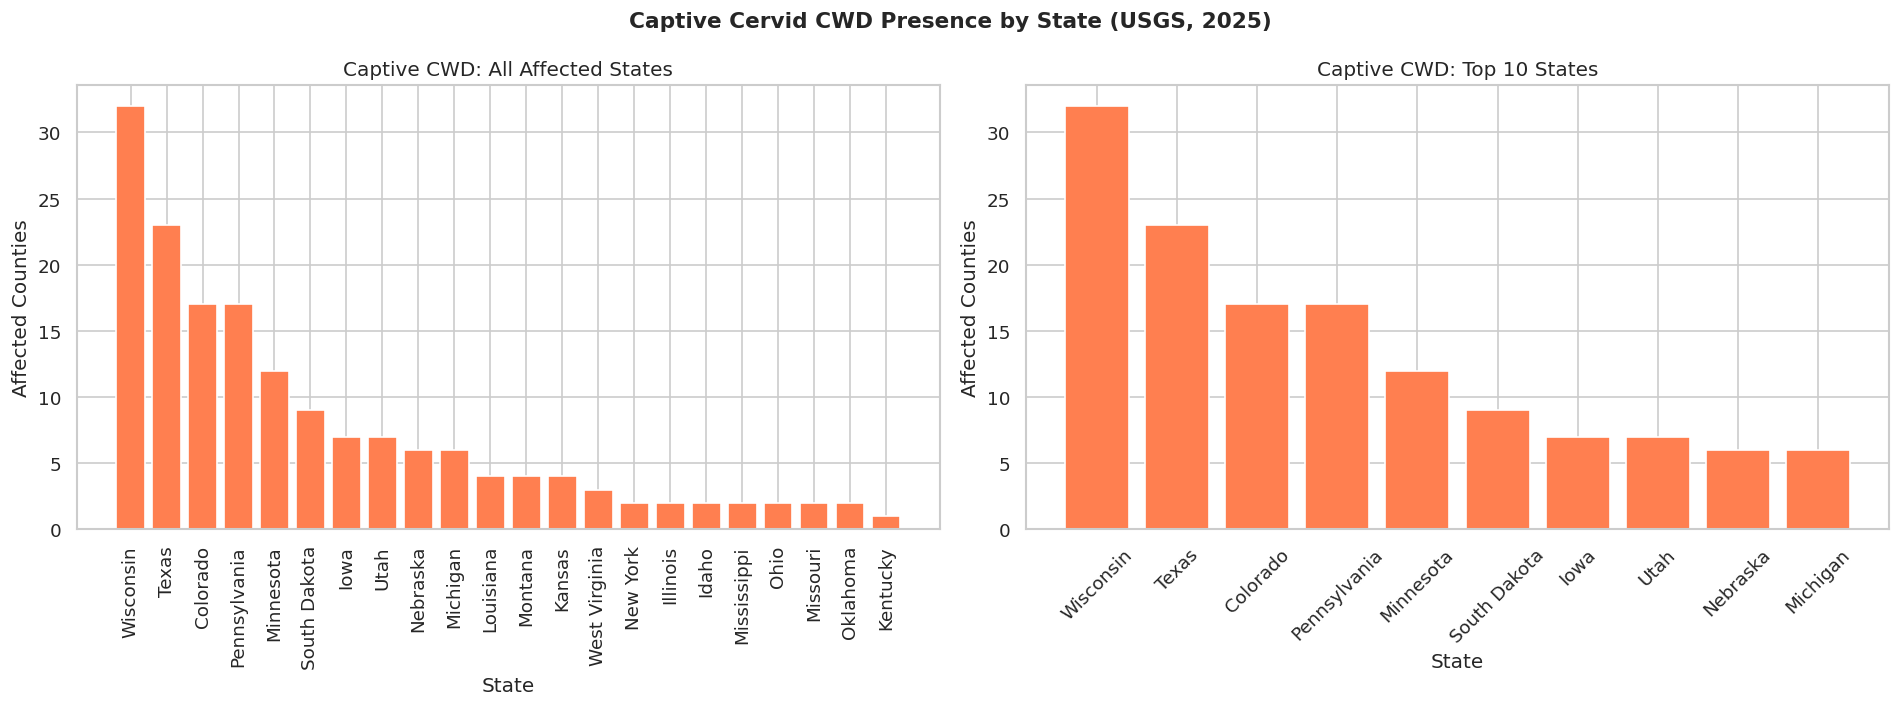

In [8]:
captive_sorted = captive_summary.sort_values(by="captive_CWD_affected_counties", ascending=False)
top10_captive = captive_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All states
axes[0].bar(captive_sorted["state"], captive_sorted["captive_CWD_affected_counties"], color="coral")
axes[0].set_title("Captive CWD: All Affected States")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Affected Counties")
axes[0].tick_params(axis="x", rotation=90)

# Top 10
axes[1].bar(top10_captive["state"], top10_captive["captive_CWD_affected_counties"], color="coral")
axes[1].set_title("Captive CWD: Top 10 States")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Affected Counties")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Captive Cervid CWD Presence by State (USGS, 2025)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** Among the 22 affected states, Wisconsin ranks first in captive CWD counties, followed by Texas and Colorado. The lower total state count (22 vs. 36 for wild) suggests captive surveillance may be more geographically concentrated or that captive-to-wild spillover has not yet registered in all states.

---
## 6. Wild vs. Captive — Comparative Analysis

Direct comparison of disease burden across the top 10 states by wild CWD presence.

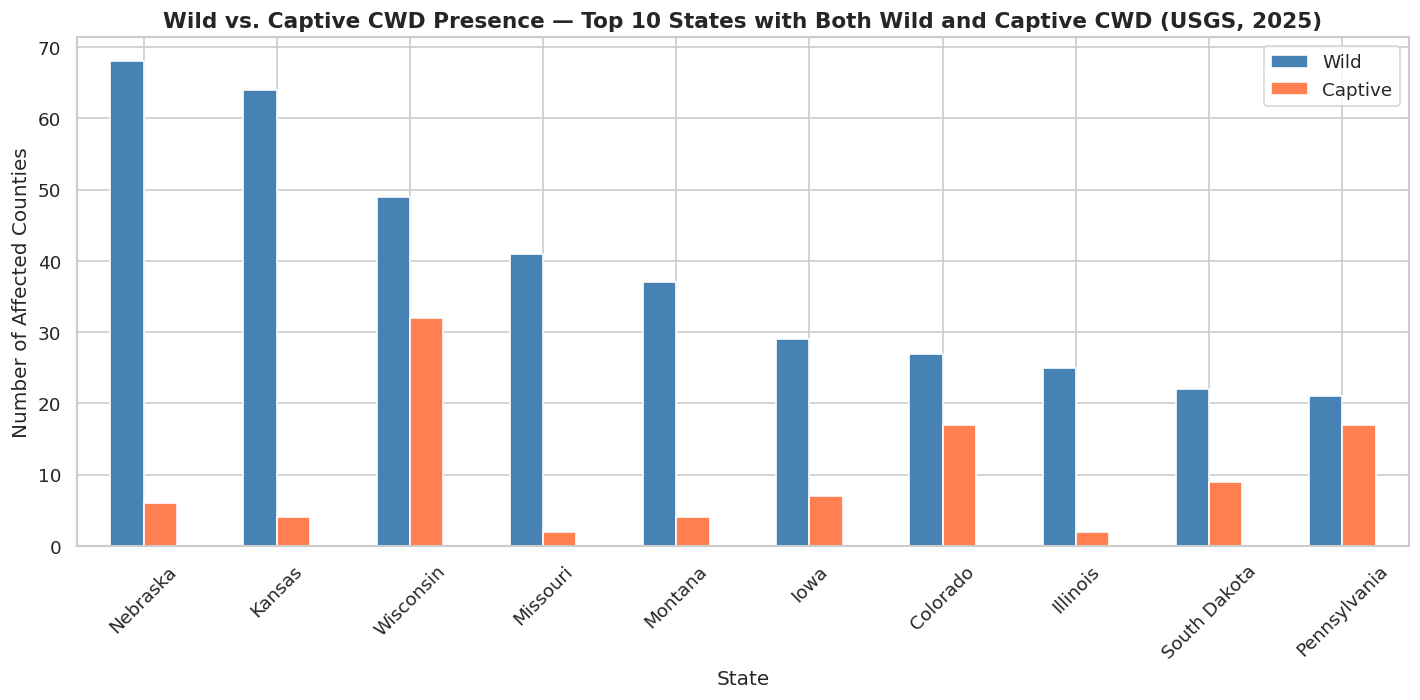

Wild-to-Captive county ratio (top 10 states with both wild and captive CWD):


,wild_CWD_affected_counties,captive_CWD_affected_counties,wild_to_captive_ratio
state,,,
Nebraska,68,6,11.3
Kansas,64,4,16.0
Wisconsin,49,32,1.5
Missouri,41,2,20.5
Montana,37,4,9.2
Iowa,29,7,4.1
Colorado,27,17,1.6
Illinois,25,2,12.5
South Dakota,22,9,2.4


In [12]:
# Merge datasets
combined = pd.merge(wild_summary, captive_summary, on="state", how="outer").fillna(0)
combined["captive_CWD_affected_counties"] = combined["captive_CWD_affected_counties"].astype(int)

# Ratio: wild vs captive - calculate this before creating top10_combined for display
combined["wild_to_captive_ratio"] = combined.apply(
    lambda r: round(r["wild_CWD_affected_counties"] / r["captive_CWD_affected_counties"], 1)
    if r["captive_CWD_affected_counties"] > 0 else None, axis=1
)

# Filter for states present in both datasets (i.e., captive_CWD_affected_counties > 0)
# Then take the top 10 states by wild presence from this filtered set
both_present_combined = combined[combined["captive_CWD_affected_counties"] > 0]
top10_both_present = both_present_combined.sort_values(by="wild_CWD_affected_counties", ascending=False).head(10).copy()

# Use top10_both_present for plotting
top10_both_present.set_index("state")[["wild_CWD_affected_counties", "captive_CWD_affected_counties"]].plot(
    kind="bar", figsize=(12, 6), color=["steelblue", "coral"],
    label=["Wild", "Captive"]
)

plt.title("Wild vs. Captive CWD Presence — Top 10 States with Both Wild and Captive CWD (USGS, 2025)", fontsize=13, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Number of Affected Counties")
plt.legend(["Wild", "Captive"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Wild-to-Captive county ratio (top 10 states with both wild and captive CWD):")
display(top10_both_present[["state", "wild_CWD_affected_counties", "captive_CWD_affected_counties", "wild_to_captive_ratio"]].set_index("state"))

**Observation:** Wild CWD burden consistently exceeds captive burden across all top-10 states. States like Wisconsin and Colorado, however, show a notably smaller wild-to-captive ratio, indicating relatively higher captive facility involvement — possibly reflecting more intensive captive deer farming, differences in surveillance protocols, or documented spillover events between captive and wild populations.

---
## 7. Key Insights

| # | Insight |
|---|--------|
| 1 | **Regional concentration:** CWD is not uniformly distributed — it clusters heavily in Midwestern states, with Nebraska (68 counties), Kansas, and Wisconsin leading. |
| 2 | **Wild > Captive burden:** Wild populations affect 36 states and 593 counties vs. 22 states and 166 counties for captive populations — roughly 3.6× more counties. |
| 3 | **Wisconsin & Colorado outliers:** These states show the highest captive-to-wild ratio, suggesting elevated captive facility exposure or spillover risk. |
| 4 | **Surveillance gap hypothesis:** The lower geographic spread in captive populations may partially reflect surveillance intensity differences rather than true disease absence. |

---
## 8. Next Steps

This exploratory analysis lays the foundation for further investigation. Potential extensions include:

- **Temporal trend analysis:** Incorporate year-of-detection data to assess whether CWD is accelerating geographically.
- **Spatial clustering (GeoPandas/Folium):** Map county-level presence to visualize true geographic spread beyond state-level aggregation.
- **Correlation analysis:** Examine whether factors such as deer population density or land use type associate with CWD prevalence.
- **Risk interface mapping:** Identify counties where both wild and captive populations are affected — high-risk zones for bidirectional transmission.